In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [ ]:
vocab_size = 10000

max_length = 200

batch_size = 64

epochs = 3

In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

In [ ]:
word_index = imdb.get_word_index()

In [ ]:
reverse_word_index = {
    value: key
    for key, value in word_index.items()
}

In [ ]:
def decode_review(review):

    words = []

    for word_id in review:

        if word_id >= 3:

            word = reverse_word_index.get(
                word_id - 3,
                "?"
            )

            words.append(word)

    return " ".join(words)

In [ ]:
print("Review:")
print(decode_review(X_train[0]))

print("\nActual Sentiment:")

if y_train[0] == 1:
    print("Positive")
else:
    print("Negative")

Review:
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also to the two little boy's that played the of norman and paul they were just brilliant children are often left out of the list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the

In [ ]:
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [ ]:
X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)


In [ ]:
model = Sequential([

    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True
    ),

    GRU(
        128
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.5
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,393 (5.29 MB)

 Trainable params: 1,387,393 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=1,

    min_lr=1e-6

)

In [ ]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=epochs,

    batch_size=batch_size,

    callbacks=[

        early_stopping,

        reduce_lr

    ]

)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 498ms/step - accuracy: 0.7404 - loss: 0.5087 - val_accuracy: 0.8462 - val_loss: 0.3691 - learning_rate: 0.0010
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 154s 491ms/step - accuracy: 0.8751 - loss: 0.3178 - val_accuracy: 0.8452 - val_loss: 0.3754 - learning_rate: 0.0010
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 495ms/step - accuracy: 0.9366 - loss: 0.1819 - val_accuracy: 0.8730 - val_loss: 0.3153 - learning_rate: 5.0000e-04


In [ ]:
test_loss, test_accuracy = model.evaluate(

    X_test,

    y_test

)


print("\nTest Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.8614 - loss: 0.3411

Test Loss: 0.34109827876091003
Test Accuracy: 0.8614000082015991


In [ ]:
y_probability = model.predict(

    X_test

)

782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step


In [ ]:
y_pred = (

    y_probability >= 0.5

).astype(int).flatten()

In [ ]:
print("\nClassification Report:")

print(

    classification_report(

        y_test,

        y_pred,

        target_names=[

            "Negative",

            "Positive"

        ]

    )

)


Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86     12500
    Positive       0.86      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [ ]:
cm = confusion_matrix(

    y_test,

    y_pred

)

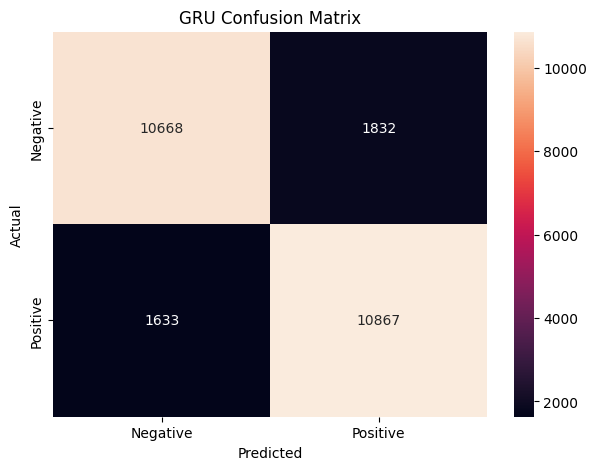

In [ ]:
plt.figure(figsize=(7, 5))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=[

        "Negative",

        "Positive"

    ],

    yticklabels=[

        "Negative",

        "Positive"

    ]

)
plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("GRU Confusion Matrix")

plt.show()

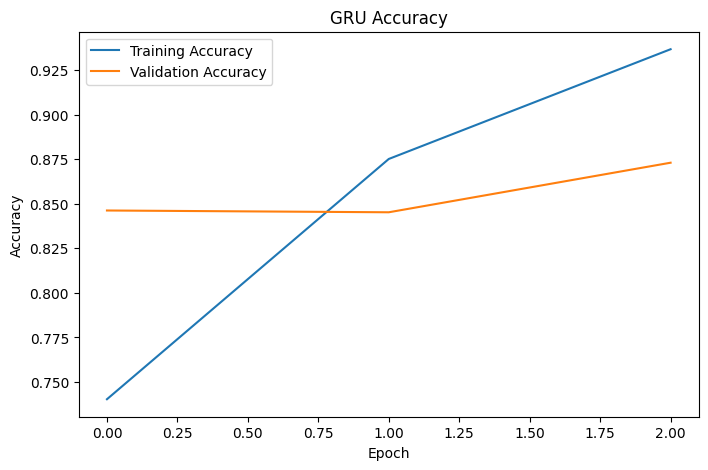

In [ ]:
plt.figure(figsize=(8, 5))


plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)


plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)


plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("GRU Accuracy")

plt.legend()
plt.show()

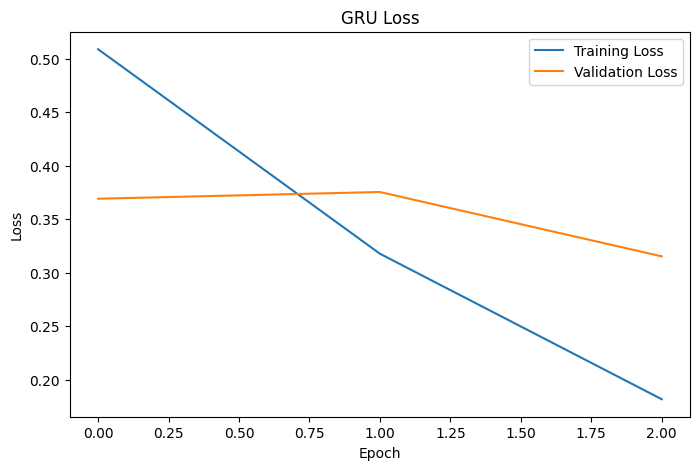

In [ ]:
plt.figure(figsize=(8, 5))


plt.plot(

    history.history["loss"],

    label="Training Loss"

)


plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("GRU Loss")

plt.legend()
plt.show()

In [ ]:
sample_index = 10

sample = X_test[sample_index]


print("\n" + "=" * 60)

print("SAMPLE REVIEW")

print("=" * 60)


print(

    decode_review(sample)

)


SAMPLE REVIEW
inspired by hitchcock's strangers on a train concept of two men murders in exchange for getting rid of the two people messing up their lives throw from the train is an original and very inventive comedy take on the idea it's a credit to danny that he both wrote and starred in this minor comedy gem br br anne is the mother who the film's title and it's understandable why she gets under the skin of danny with her sharp tongue and relentlessly putting him down for any minor billy crystal is the writer who's wife has stolen his book idea and is now being as a great new author even appearing on the oprah show to in he should be enjoying thus gets the idea of murders to rid themselves of these factors br br of course everything and anything can happen when writer carl lets his imagination with ideas for how the plot develops and it's amusing all the way through providing plenty of laughs and chuckles along the way as well as a good deal of suspense br br for


In [ ]:

prediction = model.predict(

    np.expand_dims(

        sample,

        axis=0

    )

)


probability = prediction[0][0]


print("\nProbability:", probability)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

Probability: 0.9543659


In [ ]:
if probability >= 0.5:

    print("Predicted: Positive")

else:

    print("Predicted: Negative")

Predicted: Positive


In [ ]:
if y_test[sample_index] == 1:

    print("Actual: Positive")

else:

    print("Actual: Negative")

Actual: Positive
